In [3]:
!pip install open3d torch torchvision torchaudio scikit-learn h5py tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.0 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

DATA_PATH = "/content/s3dis_dataset_5M.npy"   # тут твой файл

data = np.load(DATA_PATH)              # (N, 7)
points = data[:, :6].astype(np.float32)  # (N, 6) x,y,z,r,g,b
labels = data[:, 6].astype(np.int64)     # (N,)

print("points:", points.shape, "labels:", labels.shape)
n_classes = int(labels.max()) + 1
print("num classes:", n_classes)

# разобьём по точкам (простой вариант)
idx_all = np.arange(points.shape[0])
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, labels, test_size=0.3, random_state=42, stratify=labels
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

print("Train points:", len(idx_train))
print("Val points  :", len(idx_val))
print("Test points :", len(idx_test))

points: (5000000, 6) labels: (5000000,)
num classes: 13
Train points: 3500000
Val points  : 750000
Test points : 750000


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class S3DISPointDataset(Dataset):
    def __init__(self, points, labels, indices, num_points=4096, augment=False):
        """
        points : (N, 6)
        labels : (N,)
        indices: массив индексов (подмножество N) для этого split'а
        """
        self.points = points
        self.labels = labels
        self.indices = np.array(indices)
        self.num_points = num_points
        self.augment = augment

        # сколько "блоков" считаем за одну эпоху
        self.length = max(1, len(self.indices) // self.num_points)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # случайно выбираем num_points индексов из этого сплита
        choice = np.random.choice(self.indices, self.num_points, replace=False)
        pts = self.points[choice]      # (K, 6)
        lbl = self.labels[choice]      # (K,)

        # центрируем + нормализуем XYZ внутри блока
        xyz = pts[:, :3]
        rgb = pts[:, 3:] / 255.0
        centroid = xyz.mean(axis=0)
        xyz = xyz - centroid
        scale = np.max(np.linalg.norm(xyz, axis=1))
        if scale > 0:
            xyz = xyz / scale

        feats = np.concatenate([xyz, rgb], axis=1)  # (K, 6)

        if self.augment:
            # простая аугментация: небольшое случайное вращение вокруг Z
            theta = np.random.uniform(-np.pi/18, np.pi/18)
            rot = np.array([[ np.cos(theta), -np.sin(theta), 0],
                            [ np.sin(theta),  np.cos(theta), 0],
                            [ 0            ,  0            , 1]], dtype=np.float32)
            xyz = (xyz @ rot.T)
            feats[:, :3] = xyz

        feats = torch.from_numpy(feats).float()
        lbl = torch.from_numpy(lbl).long()
        return feats, lbl

NUM_POINTS = 2048  # можно 1024 / 4096

train_dataset = S3DISPointDataset(points, labels, idx_train, num_points=NUM_POINTS, augment=True)
val_dataset   = S3DISPointDataset(points, labels, idx_val,   num_points=NUM_POINTS, augment=False)
test_dataset  = S3DISPointDataset(points, labels, idx_test,  num_points=NUM_POINTS, augment=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2)

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class TNet(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k * k)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

    def forward(self, x):
        # x: (B, k, N)
        B = x.size(0)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, 2)[0]  # (B, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        ident = torch.eye(self.k, device=x.device).view(1, self.k*self.k).repeat(B, 1)
        x = x + ident
        x = x.view(B, self.k, self.k)
        return x

class PointNetSeg(nn.Module):
    def __init__(self, num_classes, feat_dim=6, feature_transform=True):
        super().__init__()
        self.feature_transform = feature_transform

        self.input_tnet = TNet(k=3)

        self.conv1 = nn.Conv1d(feat_dim, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(128)

        self.feature_tnet = TNet(k=64)

        self.conv4 = nn.Conv1d(128, 512, 1)
        self.conv5 = nn.Conv1d(512, 2048, 1)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(2048)

        # 2048 (global) + 128 (local) = 2176
        self.conv_seg1 = nn.Conv1d(2176, 256, 1)
        self.conv_seg2 = nn.Conv1d(256, 256, 1)
        self.conv_seg3 = nn.Conv1d(256, 128, 1)
        self.conv_seg4 = nn.Conv1d(128, num_classes, 1)
        self.bn6 = nn.BatchNorm1d(256)
        self.bn7 = nn.BatchNorm1d(256)
        self.bn8 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (B, N, 6)
        B, N, _ = x.shape

        xyz = x[:, :, :3].transpose(2, 1).contiguous()   # (B, 3, N)
        rgb = x[:, :, 3:].transpose(2, 1).contiguous()   # (B, 3, N)
        feats = x.transpose(2, 1).contiguous()           # (B, 6, N) — если вдруг понадобится

        trans = self.input_tnet(xyz)                     # (B, 3, 3)
        xyz_transformed = torch.bmm(trans, xyz)          # (B, 3, N)

        feats_transformed = torch.cat([xyz_transformed, rgb], dim=1)  # (B, 6, N)

        x = F.relu(self.bn1(self.conv1(feats_transformed)))     # (B, 64, N)

        if self.feature_transform:
            trans_feat = self.feature_tnet(x)                   # (B, 64, 64)
            x = torch.bmm(trans_feat, x)                        # (B, 64, N)
        else:
            trans_feat = None

        pointfeat = F.relu(self.bn2(self.conv2(x)))             # (B, 128, N)
        pointfeat = F.relu(self.bn3(self.conv3(pointfeat)))     # (B, 128, N)

        x = F.relu(self.bn4(self.conv4(pointfeat)))             # (B, 512, N)
        x = F.relu(self.bn5(self.conv5(x)))                     # (B, 2048, N)
        x = torch.max(x, 2, keepdim=True)[0]                    # (B, 2048, 1)
        x = x.repeat(1, 1, N)                                   # (B, 2048, N)

        x = torch.cat([x, pointfeat], dim=1)                    # (B, 2176, N)

        x = F.relu(self.bn6(self.conv_seg1(x)))
        x = F.relu(self.bn7(self.conv_seg2(x)))
        x = F.relu(self.bn8(self.conv_seg3(x)))
        x = self.dropout(x)
        x = self.conv_seg4(x)                                   # (B, num_classes, N)

        x = x.transpose(2, 1).contiguous()                      # (B, N, num_classes)
        return x

In [12]:
print("Min label:", labels.min())
print("Unique labels:", np.unique(labels)[:20])

mask = labels >= 0
points = points[mask]
labels = labels[mask]


Min label: 0
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [13]:

import torch
import torch.nn as nn
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

hist = np.bincount(labels, minlength=n_classes).astype(np.float32)
class_weights = 1.0 / (hist + 1e-6)
class_weights = class_weights / class_weights.mean()
class_weights_t = torch.from_numpy(class_weights).float().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)

model = PointNetSeg(num_classes=n_classes, feat_dim=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

Device: cuda


In [14]:
from tqdm import tqdm

num_epochs = 50
train_losses, val_losses = [], []

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_points = 0

    with torch.set_grad_enabled(train):
        for pts, lbl in loader:
            pts = pts.to(device)   # (B, N, 6)
            lbl = lbl.to(device)   # (B, N)

            optimizer.zero_grad()
            logits = model(pts)    # (B, N, C)
            loss = criterion(logits.view(-1, n_classes), lbl.view(-1))

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * pts.size(0) * pts.size(1)
            total_points += pts.size(0) * pts.size(1)

    return total_loss / total_points

for epoch in tqdm(range(1, num_epochs + 1), ascii=True):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader, train=False)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

  2%|2         | 1/50 [03:02<2:28:49, 182.23s/it]

Epoch 001: train_loss=1.6374, val_loss=1.7659


  4%|4         | 2/50 [05:44<2:16:34, 170.72s/it]

Epoch 002: train_loss=0.8218, val_loss=1.1801


  6%|6         | 3/50 [08:28<2:11:16, 167.59s/it]

...

Epoch 010: train_loss=0.2155, val_loss=8.4237


 22%|##2       | 11/50 [30:16<1:46:46, 164.28s/it]

Epoch 011: train_loss=0.1968, val_loss=2.1169


Exception ignored in: <generator object tqdm.__iter__ at 0x7f29a0fbfbe0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1196, in __iter__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1302, in close
    self.display(pos=0)
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1464, in display
    def display(self, msg=None, pos=None):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [15]:
from sklearn.metrics import confusion_matrix

def evaluate_metrics(model, loader):
    model.eval()
    all_preds = []
    all_labels_np = []

    with torch.no_grad():
        for pts, lbl in loader:
            pts = pts.to(device)
            lbl = lbl.to(device)

            logits = model(pts)          # (B,N,C)
            preds = logits.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy().reshape(-1))
            all_labels_np.append(lbl.cpu().numpy().reshape(-1))

    all_preds = np.concatenate(all_preds)
    all_labels_np = np.concatenate(all_labels_np)

    cm = confusion_matrix(all_labels_np, all_preds, labels=np.arange(n_classes))
    OA = np.trace(cm) / np.sum(cm)

    IoUs = []
    for c in range(n_classes):
        TP = cm[c, c]
        FP = cm[:, c].sum() - TP
        FN = cm[c, :].sum() - TP
        denom = TP + FP + FN
        iou = TP / denom if denom > 0 else 0.0
        IoUs.append(iou)
    mIoU = float(np.mean(IoUs))

    return OA, mIoU, IoUs, cm

OA_test, mIoU_test, IoUs, cm = evaluate_metrics(model, test_loader)
print("Test OA :", OA_test)
print("Test mIoU:", mIoU_test)
print("IoU per class:", IoUs)

Test OA : 0.8351183615095629
Test mIoU: 0.6270316077871908
IoU per class: [np.float64(0.9459223880597015), np.float64(0.9391931422175871), np.float64(0.5922972572444769), np.float64(0.731556471800913), np.float64(0.48057429510465316), np.float64(0.6927898835852487), np.float64(0.5101732309200849), np.float64(0.6600374270722489), np.float64(0.5568029996121191), np.float64(0.3150979809976247), np.float64(0.5740357235309345), np.float64(0.619595006090134), np.float64(0.5333350949977539)]


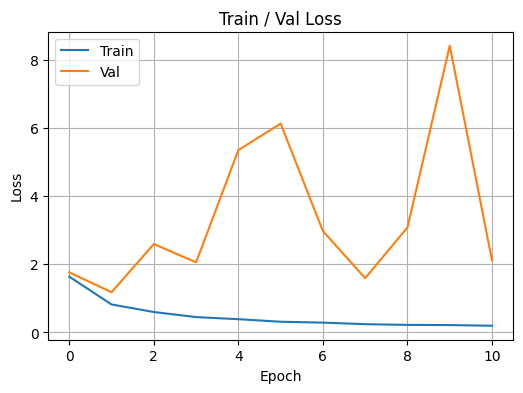

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train / Val Loss")
plt.grid(True)
plt.show()

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import numpy as np

def show_point_cloud_matplotlib(points, colors=None, title=""):
    """
    points: (N, 3) или (N, 6)
    colors: (N, 3) в [0,1], если есть
    """
    if points.shape[1] >= 3:
        xyz = points[:, :3]
    else:
        xyz = points

    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    if colors is None:
        ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], s=1)
    else:
        ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2], c=colors, s=1)
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()


In [20]:
pts_batch, lbl_batch = next(iter(test_loader))   # pts_batch: (B, N, 6)

pts_block = pts_batch[0].cpu().numpy()           # (N, 6)
lbl_block = lbl_batch[0].cpu().numpy()           # (N,)
N = pts_block.shape[0]

with torch.no_grad():
    logits = model(pts_batch.to(device))         # (B, N, num_classes)
    pred_block = logits.argmax(dim=-1)[0].cpu().numpy()   # (N,)


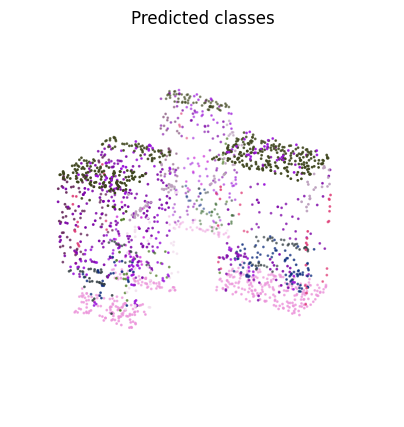

In [21]:
palette = np.random.rand(n_classes, 3)
show_point_cloud_matplotlib(pts_block, colors=palette[pred_block], title="Predicted classes")
